# Support Vector Machine (SVM)

Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification and regression tasks.  
It finds the optimal hyperplane that separates different classes with maximum margin.

Developed by Vladimir Vapnik and Corinna Cortes.

Applications:
- Spam detection
- Image classification
- Face recognition
- Text classification
- Medical diagnosis

## Objectives of SVM

- To classify data accurately
- To maximize margin between classes
- To reduce overfitting
- To improve generalization

## Important Terms

### Hyperplane
Decision boundary separating classes.

Equation:
w·x + b = 0

### Margin
Distance between hyperplane and nearest points.

Margin = 2 / ||w||

### Support Vectors
Nearest data points that define the hyperplane.

## Types of SVM

### 1. Linear SVM
Used when data is linearly separable.

### 2. Non-Linear SVM
Uses kernel trick for complex data.

### Kernel Functions
- Linear
- Polynomial
- RBF (Gaussian)
- Sigmoid

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns

In [22]:
df = pd.read_csv('letterdata.csv')
df

,letter,xbox,ybox,width,height,onpix,xbar,ybar,x2bar,y2bar,xybar
0,A,2,8,3,5,1,8,13,0,6,6
1,A,3,9,3,6,2,9,12,1,7,6
2,A,2,7,4,5,1,7,11,0,6,5
3,B,4,10,5,7,3,10,14,2,8,7
4,B,5,11,5,8,4,11,15,3,9,8
...,...,...,...,...,...,...,...,...,...,...,...
73,Y,4,10,5,7,3,10,14,2,8,7
74,Y,5,9,6,7,4,9,12,3,7,7
75,Z,3,8,4,6,2,8,12,1,6,6
76,Z,4,8,5,6,3,8,11,2,6,6


In [23]:
x = df.drop('letter', axis = 1)
y = df['letter']

<Axes: xlabel='letter', ylabel='count'>

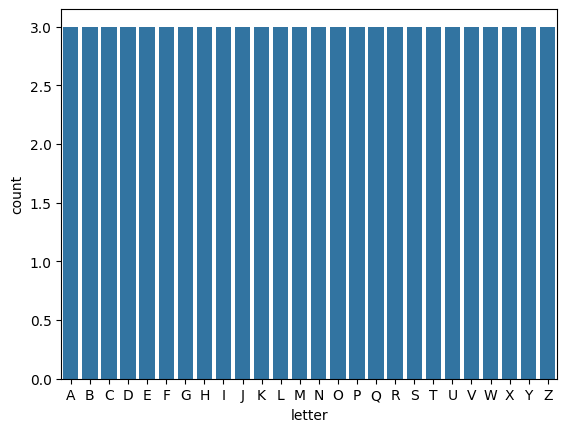

In [24]:
sns.countplot(x = y)

In [25]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                   random_state= 0,
                                                   test_size= 0.25)

In [26]:
from sklearn.svm import SVC

In [27]:
svc = SVC(kernel = 'poly')

In [28]:
svc.fit(x_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'poly'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [29]:
y_pred = svc.predict(x_test)

In [30]:
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

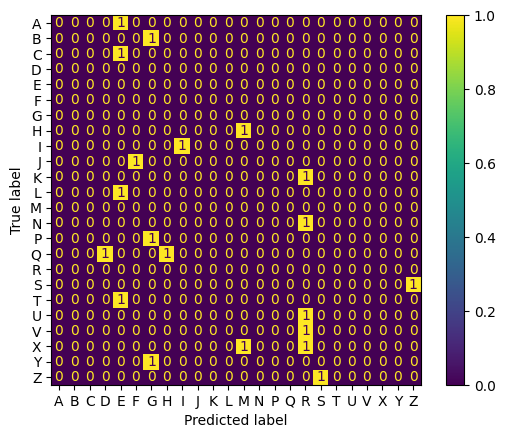

In [31]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

In [32]:
accuracy_score(y_test, y_pred)

0.05

In [36]:
import pandas as pd
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# Load data
df = pd.read_csv("letterdata.csv")

X = df.drop("letter", axis=1)
y = df["letter"]

# Encode labels
le = LabelEncoder()
y = le.fit_transform(y)

# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# VERY SMALL test split (important for small dataset)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.1,   # ⭐ key fix
    random_state=42
)

# Linear SVM (best for small data)
model = svm.SVC(kernel='linear')

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.125
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         1
           5       0.00      0.00      0.00         0
           6       0.00      0.00      0.00         0
          10       0.00      0.00      0.00         1
          11       0.00      0.00      0.00         2
          18       0.00      0.00      0.00         0
          20       0.00      0.00      0.00         0
          23       0.00      0.00      0.00         0
          25       0.00      0.00      0.00         1

    accuracy                           0.12         8
   macro avg       0.08      0.08      0.08         8
weighted avg       0.12      0.12      0.12         8

